In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.visualization import simple_norm

from spectral_cube import SpectralCube as sc
from regions import RectangleSkyRegion

%matplotlib widget

import sys
print(sys.version)
print(sys.executable)

3.13.8 | packaged by conda-forge | (main, Oct 13 2025, 14:15:33) [GCC 14.3.0]
/home/firestar/.miniforge/bin/python


In [2]:
def displayimage(cube, region=None):
    img = cube.moment(order=0).value  # moment 0
    fig, ax = plt.subplots(
        figsize=(5, 3), layout="compressed", subplot_kw={"projection": cube.wcs.celestial}
    )
    norm = simple_norm(np.array(img), vmin=0, vmax=np.max(img), stretch="linear")
    im = ax.imshow(img, norm=norm, cmap="viridis", origin="lower")
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter("dd")
    lat.set_major_formatter("dd")
    lon.set_axislabel("RA")
    lat.set_axislabel("Dec")
    if region != None:
        region.plot(color="white")
    plt.colorbar(im)
    plt.show()

In [6]:
# Combine CRAFTS data cubes

file1 = "../CRAFTS/South/Baseline Corrected/CRAFTS_RA100_120_DEC-13_2_cor_+.fits"  # -10 ~ -30
file2 = "../CRAFTS/South/Baseline Corrected/CRAFTS_RA120_140_DEC-13_2_cor_+.fits"  # 10 ~ -10

cube1 = sc.read(file1)
subcube1 = cube1.subcube(zlo=100 * u.km/u.s, zhi=300 * u.km/u.s)
print(subcube1)
data1 = subcube1.unmasked_data[:, :, :].value
data1 = np.nan_to_num(data1)
del cube1

cube2 = sc.read(file2)
subcube2 = cube2.subcube(zlo=100 * u.km/u.s, zhi=300 * u.km/u.s)
print(subcube2)
data2 = subcube2.unmasked_data[:, :, :].value
data2 = np.nan_to_num(data2)
del cube2

SpectralCube with shape=(836, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:   100.012500 deg:  119.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:    836  type_s: VRAD      unit_s: m / s  range:   131969.979 m / s:  300041.780 m / s


SpectralCube with shape=(801, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:   120.012500 deg:  139.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:    801  type_s: VRAD      unit_s: m / s  range:   139014.904 m / s:  300041.780 m / s


SpectralCube with shape=(995, 221, 481):
 n_x:    481  type_x: RA---CAR  unit_x: deg    range:   112.987500 deg:  124.987500 deg
 n_y:    221  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:   -7.487500 deg
 n_s:    995  type_s: VRAD      unit_s: m / s  range:    99965.887 m / s:  300041.780 m / s


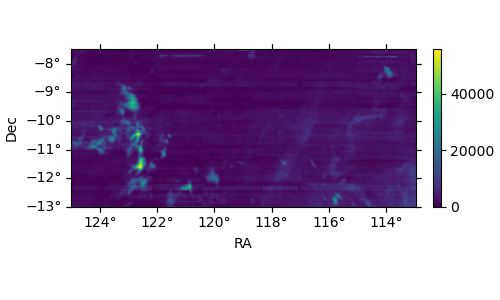

In [ ]:
# Combine the images
combined_data = np.concatenate((data2, data1), axis=2)

# Update the header for the new combined image
combined_header = subcube2.wcs.to_header()
combined_wcs = WCS(combined_header)

combined_cube = sc(data=combined_data, wcs=combined_wcs)

test_cube = combined_cube.subcube(xlo=113*u.deg, xhi=125*u.deg, ylo=-13*u.deg, yhi=-7.5*u.deg)
test_cube.write("test.fits", format="fits", overwrite=True)

print(test_cube)
displayimage(test_cube)

In [ ]:
hi4pi_cube = sc.read("../HI4PI/HI4PI_ALLSKY_EQ2000_CAR.fits")
hi4pi_test_cube = hi4pi_cube.subcube(xlo=113*u.deg, xhi=125*u.deg, ylo=-13*u.deg, yhi=-7.5*u.deg, zlo=100 * u.km/u.s, zhi=300 * u.km/u.s)
print(hi4pi_test_cube)
del hi4pi_test_cube.header["SLICE"]
hi4pi_test_cube.write("hi4pi_test.fits", format="fits", overwrite=True)

SpectralCube with shape=(156, 67, 145) and unit=K:
 n_x:    145  type_x: RA---CAR  unit_x: deg    range:   113.000000 deg:  125.000000 deg
 n_y:     67  type_y: DEC--CAR  unit_y: deg    range:   -13.000000 deg:   -7.500000 deg
 n_s:    156  type_s: VRAD      unit_s: m / s  range:   100581.725 m / s:  300255.045 m / s


In [7]:
# Combine CRAFTS data cubes

file3 = "../CRAFTS/South/Baseline Corrected/CRAFTS_RA60_80_DEC-13_2_cor_-.fits"

cube3 = sc.read(file3)
subcube3 = cube3.subcube(xlo=60*u.deg, xhi=80*u.deg, ylo=-6*u.deg, yhi=-2*u.deg, zlo=-255 * u.km/u.s, zhi=-55 * u.km/u.s)
print(subcube3)
subcube3.write("test2.fits", format="fits", overwrite=True)

SpectralCube with shape=(995, 161, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:    60.012500 deg:   79.987500 deg
 n_y:    161  type_y: DEC--CAR  unit_y: deg    range:    -5.987500 deg:   -1.987500 deg
 n_s:    995  type_s: VRAD      unit_s: m / s  range:  -255098.374 m / s:  -55022.481 m / s


In [8]:
hi4pi_cube = sc.read("../HI4PI/HI4PI_ALLSKY_EQ2000_CAR.fits")
hi4pi_test_cube2 = hi4pi_cube.subcube(xlo=60*u.deg, xhi=80*u.deg, ylo=-6*u.deg, yhi=-2*u.deg, zlo=-255 * u.km/u.s, zhi=-55 * u.km/u.s)
print(hi4pi_test_cube2)
hi4pi_test_cube2.write("hi4pi_test2.fits", format="fits", overwrite=True)

SpectralCube with shape=(156, 49, 241) and unit=K:
 n_x:    241  type_x: RA---CAR  unit_x: deg    range:    60.000000 deg:   80.000000 deg
 n_y:     49  type_y: DEC--CAR  unit_y: deg    range:    -6.000000 deg:   -2.000000 deg
 n_s:    156  type_s: VRAD      unit_s: m / s  range:  -254965.606 m / s:  -55292.286 m / s
